In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
)

import warnings
warnings.filterwarnings("ignore")

print("All lib imported")

All lib imported


In [2]:
data=pd.read_csv("../dataset/SMSSpamCollection",sep="\t",header=None,names=["label","message"])
data.head()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/SMSSpamCollection'

In [3]:
data = pd.read_csv(
    "../dataset/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

data.head()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/SMSSpamCollection'

In [4]:
data = pd.read_csv(
    "dataset/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print("Number of Rows:",data.shape[0])
print("Number of Columns:",data.shape[1])

Number of Rows: 5572
Number of Columns: 2


In [6]:
data.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [7]:
data.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
print("Duplicate rows:",data.duplicated().sum())

Duplicate rows: 403


In [9]:
data["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

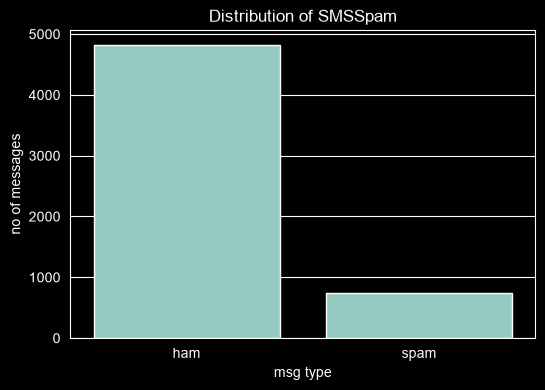

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=data,x="label")

plt.title("Distribution of SMSSpam")
plt.xlabel("msg type")
plt.ylabel("no of messages")

plt.show()

In [11]:
print("Duplicate rows : ",data.duplicated().sum())


Duplicate rows :  403


In [12]:
data=data.drop_duplicates()
print("dataset after dropping duplicate rows : ",data.shape)

dataset after dropping duplicate rows :  (5169, 2)


In [13]:
print("Duplicated rows:",data.duplicated().sum())

Duplicated rows: 0


In [14]:
data["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

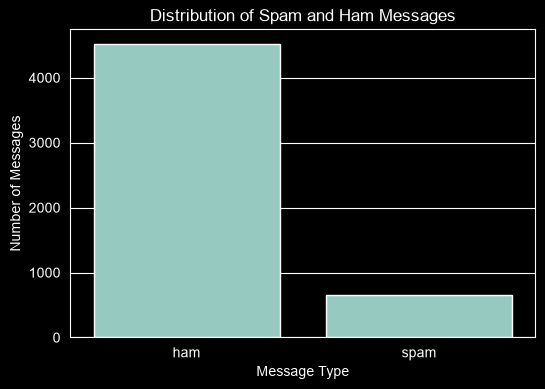

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=data, x="label")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [16]:
data["label"]=data["label"].map({"ham":0,"spam":1})
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [26]:
sample_message = "Congratulations!!! You've WON £1000!!! Visit http://example.com"

print("Original:")
print(sample_message)

print("\nCleaned:")
print(clean_text(sample_message))

Original:
Congratulations!!! You've WON £1000!!! Visit http://example.com

Cleaned:
congratulations youve won visit


In [27]:
data["clean_message"]=data["message"].apply(clean_text)

In [28]:
data[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


In [29]:
empty_message=data["clean_message"].str.strip().eq("").sum()
print("Empty message:",empty_message)

Empty message: 3


In [30]:
data = data[data["clean_message"].str.strip() != ""]

In [31]:
empty_message = data["clean_message"].str.strip().eq("").sum()
print("Empty message:", empty_message)

Empty message: 0


In [32]:
x=data["clean_message"]
y=data["label"]
print("number of msg:",len(x))
print("number of label:",len(y))

number of msg: 5166
number of label: 5166


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

NameError: name 'X' is not defined

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [35]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4132
Testing samples: 1034
